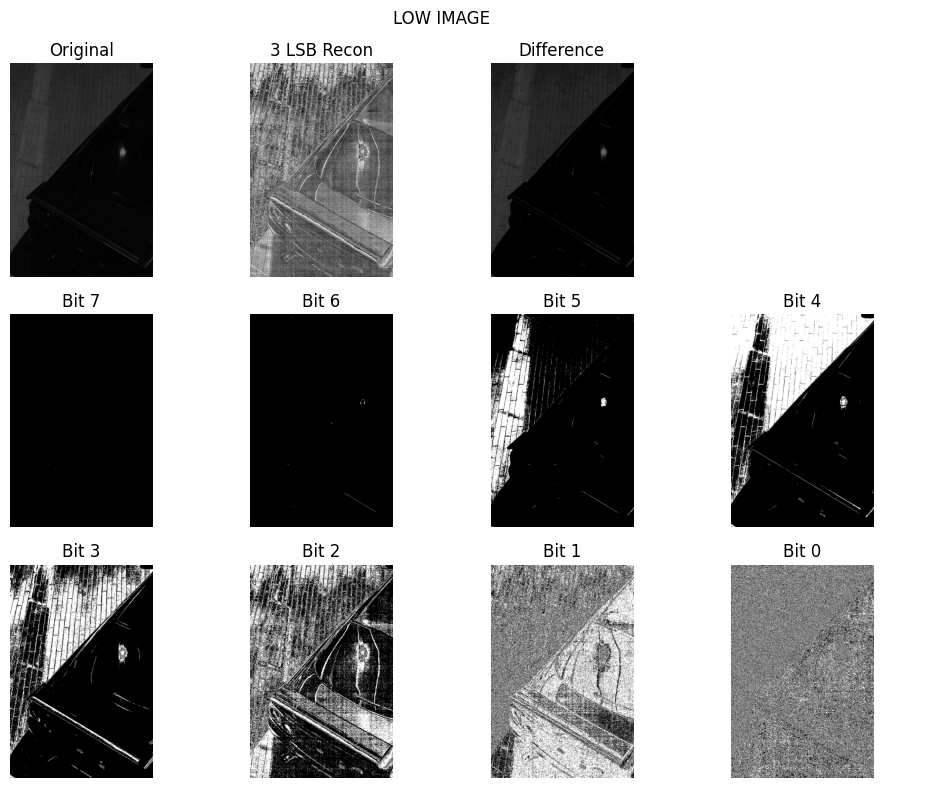

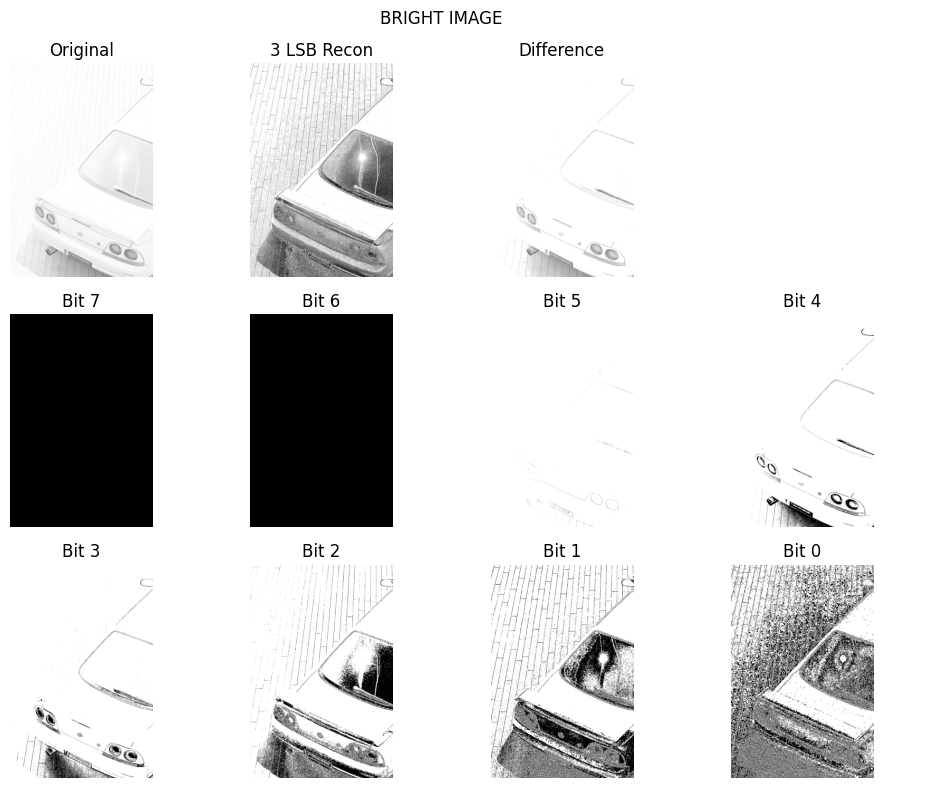

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------- helper functions ----------

def bitplane_decomposition(img_gray):
    """
    img_gray : 8-bit grayscale image (numpy array)
    returns 8 bit-planes in a list:
    planes[0] = LSB, planes[7] = MSB
    """
    planes = []
    for k in range(8):
        plane = (img_gray >> k) & 1
        planes.append(plane.astype(np.uint8))
    return planes


def reconstruct_from_3_LSB(planes):
    """
    Reconstruct image using 3 least significant bits
    """
    recon = (planes[0] * 1 +
             planes[1] * 2 +
             planes[2] * 4).astype(np.uint8)
    return recon


def make_montage(img, planes, recon, diff, title):
    """
    Display 3×4 montage
    """
    plt.figure(figsize=(10, 8))

    # Row 1
    plt.subplot(3, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(3, 4, 2)
    plt.imshow(recon, cmap='gray')
    plt.title('3 LSB Recon')
    plt.axis('off')

    plt.subplot(3, 4, 3)
    plt.imshow(diff, cmap='gray')
    plt.title('Difference')
    plt.axis('off')

    plt.subplot(3, 4, 4)
    plt.axis('off')

    # Row 2: Bit 7 to Bit 4
    idx = 5
    for b in range(7, 3, -1):
        plt.subplot(3, 4, idx)
        plt.imshow(planes[b] * 255, cmap='gray')
        plt.title(f'Bit {b}')
        plt.axis('off')
        idx += 1

    # Row 3: Bit 3 to Bit 0
    idx = 9
    for b in range(3, -1, -1):
        plt.subplot(3, 4, idx)
        plt.imshow(planes[b] * 255, cmap='gray')
        plt.title(f'Bit {b}')
        plt.axis('off')
        idx += 1

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def process_image(path, prefix):
    """
    Process a single image for bit-plane analysis
    """

    # ---- FILE EXISTENCE CHECK ----
    if not os.path.exists(path):
        raise FileNotFoundError(f"File does not exist: {path}")

    # Read image
    img_color = cv2.imread(path)

    # ---- IMAGE LOAD CHECK ----
    if img_color is None:
        raise ValueError(f"Failed to load image: {path}")

    # Convert to grayscale
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # Bit-plane decomposition
    planes = bitplane_decomposition(img_gray)

    # Reconstruction using 3 LSBs
    recon = reconstruct_from_3_LSB(planes)

    # Difference image
    diff = cv2.absdiff(img_gray, recon)

    # Save outputs
    cv2.imwrite(f'{prefix}_original.png', img_gray)
    cv2.imwrite(f'{prefix}_recon_3LSB.png', recon)
    cv2.imwrite(f'{prefix}_difference.png', diff)

    for k, p in enumerate(planes):
        cv2.imwrite(f'{prefix}_bitplane_{k}.png', p * 255)

    # Display montage
    make_montage(img_gray, planes, recon, diff, f'{prefix.upper()} IMAGE')


# ---------- main ----------

if __name__ == "__main__":

    # Provide correct paths
    low_image_path = "/content/Image1 (1).jpeg"        # low-light image
    bright_image_path = "/content/Image2 (1).jpeg"  # bright-light image

    process_image(low_image_path, "low")
    process_image(bright_image_path, "bright")
